In [0]:
# !pip install torch_geometric 
# %pip install s3fs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 184.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2023.5.0
    Not uninstalling fsspec at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-eeb35a66-d683-4ab5-a6c2-3409b9ca08d0
    Can't uninstall 'fsspec'. No files were found to uninstall.
  Attempting uninstall: aiosignal
    Found existing installation: aiosignal 1.2.0
    Not uninstalling aiosignal at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-eeb35a66-d683-4ab5-a6c2-3409b9ca08d0
    Can't uninstall 'aiosignal'. No files were found to uninstall.
  Attempting uninstall: aiohappyeyeballs
    Found existing installation: aiohappyeyeballs 2.4.4
    Not uninstalling aiohappyeyeballs at /databricks/python3/lib/python3.12/site-packag

In [0]:
%restart_python or dbutils.library.restartPython()

In [0]:
import json
import concurrent.futures
import numpy as np
import matplotlib.pyplot as plt
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
 
import s3fs
import pyarrow.parquet as pq
import pyarrow as pa
from sklearn.metrics import roc_auc_score, average_precision_score
 
print("Imports OK")

Imports OK


In [0]:
S3_ROOT        = "s3://university-research-s20426/tgnn_dataset_v2"
 
PERIODS        = 6          # look-back window (6 minutes)
BATCH_SIZE     = 4          # small batch — each item is (N_active, F, T)
HIDDEN_DIM     = 32         # GCN + GRU hidden size
EPOCHS         = 20
LR             = 0.001
RT_ANOMALY_PCT = 0.95       # top 5% RT = anomaly
MAX_WORKERS    = 16         # parallel S3 threads
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

Device : cpu


In [0]:
fs = s3fs.S3FileSystem(
   
)
 
 
def read_parquet_dir(directory):
    """Read a partitioned parquet directory file-by-file via s3fs."""
    files = [f for f in fs.ls(directory) if f.endswith(".parquet")]
    if not files:
        return None
    tables = []
    for f in files:
        with fs.open(f, "rb") as fh:
            tables.append(pq.read_table(fh))
    return pa.concat_tables(tables).to_pandas()
 
 
def load_manifest(split):
    files = fs.ls(f"{S3_ROOT}/manifests/{split}")
    part  = [f for f in files if "part-" in f][0]
    with fs.open(part) as fh:
        content = fh.read()
        if isinstance(content, bytes):
            content = content.decode("utf-8")
        parsed = json.loads(content.strip())
        if isinstance(parsed, str):
            parsed = json.loads(parsed)
        return parsed
 
 
def load_stats():
    files = fs.ls(f"{S3_ROOT}/dataset_stats")
    part  = [f for f in files if "part-" in f][0]
    with fs.open(part) as fh:
        content = fh.read()
        if isinstance(content, bytes):
            content = content.decode("utf-8")
        parsed = json.loads(content.strip())
        if isinstance(parsed, str):
            parsed = json.loads(parsed)
        return parsed
 
 
def load_snapshot_raw(t_idx, split):
    """Load raw DataFrames for one snapshot. Returns (nodes_df, edges_df)."""
    node_dir = f"{S3_ROOT}/snapshots/{split}/nodes/t_idx={t_idx}"
    edge_dir = f"{S3_ROOT}/snapshots/{split}/edges/t_idx={t_idx}"
    try:
        nodes_df = read_parquet_dir(node_dir)
        edges_df = read_parquet_dir(edge_dir)
        if nodes_df is None or edges_df is None:
            return None, None
        if nodes_df.empty or edges_df.empty:
            return None, None
        return nodes_df, edges_df
    except Exception as e:
        return None, None
 
 

In [0]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. Load metadata
# ─────────────────────────────────────────────────────────────────────────────
print("\nLoading manifests and stats...")
 
train_manifest = load_manifest("train")
val_manifest   = load_manifest("val")
test_manifest  = load_manifest("test")
stats          = load_stats()
 
NODE_FEATURE_NAMES = stats["node_feature_names"]
EDGE_FEATURE_NAMES = [c for c in stats["edge_feature_names"]
                      if c != "rpctype_idx"]
NODE_FEAT_DIM      = len(NODE_FEATURE_NAMES)
EDGE_FEAT_DIM      = len(EDGE_FEATURE_NAMES)
 
print(f"Node feature dim  : {NODE_FEAT_DIM}")
print(f"Edge feature dim  : {EDGE_FEAT_DIM}")
print(f"Train snapshots   : {train_manifest['count']}")
print(f"Val   snapshots   : {val_manifest['count']}")
print(f"Test  snapshots   : {test_manifest['count']}")


Loading manifests and stats...
Node feature dim  : 27
Edge feature dim  : 4
Train snapshots   : 650
Val   snapshots   : 50
Test  snapshots   : 20


In [0]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. Compute RT anomaly threshold  (from training data only)
# ─────────────────────────────────────────────────────────────────────────────
print("\nComputing RT anomaly threshold...")
 
rt_values = []
sample_t  = train_manifest["t_indices"][::10][:30]  # 30 snapshots is enough
 
for t in sample_t:
    _, edges_df = load_snapshot_raw(t, "train")
    if edges_df is not None and "rt_log_mean_rs" in edges_df.columns:
        rt_values.extend(edges_df["rt_log_mean_rs"].dropna().tolist())
 
assert len(rt_values) > 0, "No RT values found — check snapshot loading"
 
RT_THRESHOLD = float(np.percentile(rt_values, RT_ANOMALY_PCT * 100))
print(f"RT threshold (p{int(RT_ANOMALY_PCT*100)}) : {RT_THRESHOLD:.4f}")
print(f"Collected from {len(rt_values):,} edge observations")


Computing RT anomaly threshold...
RT threshold (p95) : 5.8384
Collected from 167,363 edge observations


In [0]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. Snapshot → tensors
#    Only keeps nodes/edges ACTIVE in this snapshot (not all NUM_NODES)
#    This keeps memory manageable
# ─────────────────────────────────────────────────────────────────────────────
 
def snapshot_to_tensors(t_idx, split):
    """
    Convert one snapshot to tensors.
 
    Returns dict:
        x          : (N, NODE_FEAT_DIM)
        edge_index : (2, E)
        edge_attr  : (E, EDGE_FEAT_DIM)
        y_edge     : (E,)   binary anomaly label
        N          : int    number of active nodes
        E          : int    number of edges
    or None if snapshot is missing/empty.
    """
    nodes_df, edges_df = load_snapshot_raw(t_idx, split)
    if nodes_df is None:
        return None
 
    # ── Node features (active nodes only) ─────────────────────────────────
    feat_cols = [c for c in NODE_FEATURE_NAMES if c in nodes_df.columns]
    x = torch.tensor(
        nodes_df[feat_cols].fillna(0).values.astype(np.float32),
        dtype=torch.float,
    )   # (N, NODE_FEAT_DIM)
 
    N = len(nodes_df)
 
    # Local node index: global node_id -> 0..N-1
    local_map = {
        int(row["node_id"]): i
        for i, (_, row) in enumerate(nodes_df.iterrows())
    }
 
    # ── Edge index (remap to local) ────────────────────────────────────────
    src_g = edges_df["src_node_id"].fillna(-1).astype(int).values
    dst_g = edges_df["dst_node_id"].fillna(-1).astype(int).values
 
    # Keep only edges where both endpoints are in this snapshot
    mask      = np.array([s in local_map and d in local_map
                           for s, d in zip(src_g, dst_g)])
    edges_df  = edges_df[mask].reset_index(drop=True)
    src_local = np.array([local_map[s] for s in src_g[mask]])
    dst_local = np.array([local_map[d] for d in dst_g[mask]])
 
    edge_index = torch.tensor(
        np.stack([src_local, dst_local], axis=0), dtype=torch.long
    )   # (2, E)
 
    # ── Edge features ──────────────────────────────────────────────────────
    ef_cols   = [c for c in EDGE_FEATURE_NAMES if c in edges_df.columns]
    edge_attr = torch.tensor(
        edges_df[ef_cols].fillna(0).values.astype(np.float32),
        dtype=torch.float,
    )   # (E, EDGE_FEAT_DIM)
 
    # ── Anomaly labels ─────────────────────────────────────────────────────
    if "rt_log_mean_rs" in edges_df.columns:
        y_edge = torch.tensor(
            (edges_df["rt_log_mean_rs"].fillna(0).values
             > RT_THRESHOLD).astype(np.float32)
        )
    else:
        y_edge = torch.zeros(len(edges_df), dtype=torch.float)
 
    return {
        "x":          x,
        "edge_index": edge_index,
        "edge_attr":  edge_attr,
        "y_edge":     y_edge,
        "N":          N,
        "E":          len(edges_df),
    }
 
# Quick test
print("\nTesting snapshot loader...")
test_snap = snapshot_to_tensors(train_manifest["t_indices"][0], "train")
assert test_snap is not None, "Snapshot loading failed"
print(f"  x          : {test_snap['x'].shape}")
print(f"  edge_index : {test_snap['edge_index'].shape}")
print(f"  edge_attr  : {test_snap['edge_attr'].shape}")
print(f"  y_edge     : {test_snap['y_edge'].shape}")
print(f"  anomaly %  : {test_snap['y_edge'].mean():.3f}")
print("Snapshot loader OK")


Testing snapshot loader...
  x          : torch.Size([1303, 27])
  edge_index : torch.Size([2, 895])
  edge_attr  : torch.Size([895, 4])
  y_edge     : torch.Size([895])
  anomaly %  : 0.121
Snapshot loader OK


In [0]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. Dataset  — parallel loading + sliding windows
# ─────────────────────────────────────────────────────────────────────────────
 
class TGCNDataset(torch.utils.data.Dataset):
    """
    Loads all snapshots in parallel, then builds sliding windows.
    Each item = window of PERIODS consecutive snapshots.
    """
 
    def __init__(self, manifest, split, periods=PERIODS,
                 max_workers=MAX_WORKERS):
        self.periods = periods
        self.split   = split
        t_list       = manifest["t_indices"]
 
        # ── Parallel snapshot loading ──────────────────────────────────────
        print(f"\n[{split}] Loading {len(t_list)} snapshots "
              f"(parallel, workers={max_workers})...")
 
        cache = {}
 
        def _load(t):
            return t, snapshot_to_tensors(t, split)
 
        with concurrent.futures.ThreadPoolExecutor(
            max_workers=max_workers
        ) as ex:
            futures = {ex.submit(_load, t): t for t in t_list}
            done    = 0
            for fut in concurrent.futures.as_completed(futures):
                t, s = fut.result()
                if s is not None:
                    cache[t] = s
                done += 1
                if done % 100 == 0:
                    print(f"  {done}/{len(t_list)} loaded", end="\r")
 
        print(f"  {len(cache)}/{len(t_list)} snapshots loaded OK")
        self._cache = cache
 
        # ── Build valid consecutive windows ───────────────────────────────
        valid_t      = sorted(cache.keys())
        self.windows = []
 
        for i in range(len(valid_t) - periods):
            window = valid_t[i: i + periods]
            # Check all PERIODS snapshots are consecutive
            if window[-1] - window[0] == periods - 1:
                self.windows.append(window)
 
        print(f"  {len(self.windows)} sliding windows "
              f"(PERIODS={periods})")
 
    def __len__(self):
        return len(self.windows)
 
    def __getitem__(self, idx):
        window = self.windows[idx]
 
        # Node features stacked over time: list of (N, F) -> (N, F, T)
        frames = [self._cache[t]["x"] for t in window]
 
        # All frames must have same N — use the last snapshot's N as reference
        # Pad smaller frames with zeros if needed
        N_ref = frames[-1].size(0)
        padded = []
        for f in frames:
            N_i = f.size(0)
            if N_i < N_ref:
                pad = torch.zeros(N_ref - N_i, NODE_FEAT_DIM)
                f   = torch.cat([f, pad], dim=0)
            elif N_i > N_ref:
                f = f[:N_ref]
            padded.append(f)
 
        X    = torch.stack(padded, dim=-1)   # (N_ref, F, T)
        last = self._cache[window[-1]]
 
        return X, last["edge_index"], last["edge_attr"], last["y_edge"]
 
 
# ── Collate: pad edges to same size within a batch ────────────────────────
def collate_fn(batch):
    """
    Node tensors: pad to max_N in batch.
    Edge tensors: pad to max_E in batch.
    """
    max_N  = max(b[0].size(0) for b in batch)
    max_E  = max(b[1].size(1) for b in batch)
    f_dim  = batch[0][0].size(1)   # renamed: lowercase, no conflict with F
    t_dim  = batch[0][0].size(2)

    X_list, EI_list, EA_list, Y_list = [], [], [], []

    for X, EI, EA, Y in batch:
        N = X.size(0)
        E = EI.size(1)

        # Pad nodes if needed
        if N < max_N:
            X = torch.cat([
                X,
                torch.zeros(max_N - N, f_dim, t_dim)
            ], dim=0)

        # Pad edges
        pad_E = max_E - E
        EI    = torch.nn.functional.pad(EI, (0, pad_E),       value=0)
        EA    = torch.nn.functional.pad(EA, (0, 0, 0, pad_E), value=0.0)
        Y     = torch.nn.functional.pad(Y,  (0, pad_E),       value=0.0)

        X_list.append(X)
        EI_list.append(EI)
        EA_list.append(EA)
        Y_list.append(Y)

    return (
        torch.stack(X_list,  dim=0),   # (B, max_N, f_dim, t_dim)
        torch.stack(EI_list, dim=0),   # (B, 2, max_E)
        torch.stack(EA_list, dim=0),   # (B, max_E, edge_feat_dim)
        torch.stack(Y_list,  dim=0),   # (B, max_E)
    )
 
 
# ── Build datasets ─────────────────────────────────────────────────────────
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True,  drop_last=True,  collate_fn=collate_fn,
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,   batch_size=BATCH_SIZE,
    shuffle=False, drop_last=False, collate_fn=collate_fn,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,  batch_size=BATCH_SIZE,
    shuffle=False, drop_last=False, collate_fn=collate_fn,
)
 
print(f"\nTrain batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")


Train batches : 161
Val   batches : 11
Test  batches : 4


In [0]:
class TGCNCell(nn.Module):
    """
    One step of TGCN:
      GCN spatial aggregation -> GRU temporal update
    """
    def __init__(self, in_channels, hidden_dim):
        super().__init__()
        self.gcn = GCNConv(in_channels, hidden_dim, add_self_loops=True)
        self.gru = nn.GRUCell(hidden_dim, hidden_dim)
 
    def forward(self, x, edge_index, h):
        """
        x          : (N, in_channels)
        edge_index : (2, E)
        h          : (N, hidden_dim)
        returns h_new : (N, hidden_dim)
        """
        gcn_out = self.gcn(x, edge_index)   # (N, hidden_dim)
        gcn_out = F.relu(gcn_out)
        h_new   = self.gru(gcn_out, h)      # (N, hidden_dim)
        return h_new
 
 
class TGCN(nn.Module):
    """
    Full TGCN model:
      - TGCNCell unrolled over PERIODS time steps
      - Edge anomaly head on final hidden state
    """
    def __init__(self, node_feat_dim, hidden_dim, periods):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.periods    = periods
 
        self.tgcn_cell = TGCNCell(node_feat_dim, hidden_dim)
 
        # Edge anomaly head: concat(src_h, dst_h) -> score
        self.edge_head = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid(),
        )
 
    def forward(self, x, edge_index):
        """
        x          : (B, N, F, T)
        edge_index : (B, 2, E)
 
        Returns scores : (B, E)
        """
        B, N, F, T = x.shape
        device      = x.device
 
        all_scores = []
 
        for b in range(B):
            x_b  = x[b]           # (N, F, T)
            ei_b = edge_index[b]  # (2, E)
 
            # Initial hidden state
            h = torch.zeros(N, self.hidden_dim, device=device)
 
            # Unroll over time steps
            for t in range(T):
                x_t = x_b[:, :, t]             # (N, F)
                h   = self.tgcn_cell(x_t, ei_b, h)
 
            # h is now (N, hidden_dim) — encodes spatiotemporal info
 
            # Edge anomaly score: use src + dst hidden states
            src     = ei_b[0]                  # (E,)
            dst     = ei_b[1]                  # (E,)
            src_h   = h[src]                   # (E, hidden_dim)
            dst_h   = h[dst]                   # (E, hidden_dim)
            edge_h  = torch.cat([src_h, dst_h], dim=-1)  # (E, 2*hidden)
            scores  = self.edge_head(edge_h).squeeze(-1)  # (E,)
 
            all_scores.append(scores)
 
        return torch.stack(all_scores, dim=0)  # (B, E)
 
 
# Instantiate
model     = TGCN(
    node_feat_dim=NODE_FEAT_DIM,
    hidden_dim=HIDDEN_DIM,
    periods=PERIODS,
).to(DEVICE)
 
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
 
print("\nModel:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
 


Model:
TGCN(
  (tgcn_cell): TGCNCell(
    (gcn): GCNConv(27, 32)
    (gru): GRUCell(32, 32)
  )
  (edge_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
    (4): Sigmoid()
  )
)

Total parameters: 9,345


In [0]:
# ─────────────────────────────────────────────────────────────────────────────
# 8. Loss — Focal Loss for imbalanced anomaly detection
# ─────────────────────────────────────────────────────────────────────────────
 
def focal_loss(pred, target, gamma=2.0, alpha=0.25):
    """
    pred, target : (B, E) — values in [0, 1]
    Downweights easy negatives so model focuses on rare anomalies.
    """
    bce = F.binary_cross_entropy(pred, target, reduction="none")
    pt  = torch.where(target == 1, pred, 1 - pred)
    w   = torch.where(
        target == 1,
        torch.full_like(pred, alpha),
        torch.full_like(pred, 1 - alpha),
    )
    return (w * (1 - pt) ** gamma * bce).mean()

In [0]:
# ─────────────────────────────────────────────────────────────────────────────
# 9. Training Loop
# ─────────────────────────────────────────────────────────────────────────────
 
train_loss_history = []
val_auroc_history  = []
best_val_auroc     = 0.0
 
print("\nStarting training...")
 
for epoch in range(EPOCHS):
 
    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    loss_list = []
 
    for step, (X_b, EI_b, EA_b, Y_b) in enumerate(train_loader):
        X_b  = X_b.to(DEVICE)    # (B, N, F, T)
        EI_b = EI_b.to(DEVICE)   # (B, 2, E)
        Y_b  = Y_b.to(DEVICE)    # (B, E)
 
        y_hat = model(X_b, EI_b)             # (B, E)
        loss  = focal_loss(y_hat, Y_b)
 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
 
        loss_list.append(loss.item())
 
        if (step + 1) % 20 == 0:
            print(
                f"  Epoch {epoch+1:2d}  "
                f"step {step+1:4d}/{len(train_loader)}  "
                f"loss={np.mean(loss_list):.4f}",
                end="\r"
            )
 
    epoch_loss = float(np.mean(loss_list))
    train_loss_history.append(epoch_loss)
 
    # ── Validation ─────────────────────────────────────────────────────────
    model.eval()
    all_preds, all_targets = [], []
 
    with torch.no_grad():
        for X_b, EI_b, EA_b, Y_b in val_loader:
            X_b  = X_b.to(DEVICE)
            EI_b = EI_b.to(DEVICE)
 
            y_hat = model(X_b, EI_b)
            all_preds.append(y_hat.cpu().numpy().flatten())
            all_targets.append(Y_b.numpy().flatten())
 
    all_preds   = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
 
    if all_targets.sum() > 0:
        val_auroc = roc_auc_score(all_targets, all_preds)
        val_auprc = average_precision_score(all_targets, all_preds)
    else:
        val_auroc = val_auprc = 0.0
 
    val_auroc_history.append(val_auroc)
 
    print(
        f"Epoch {epoch+1:2d}/{EPOCHS}  "
        f"loss={epoch_loss:.4f}  "
        f"val_AUROC={val_auroc:.4f}  "
        f"val_AUPRC={val_auprc:.4f}  "
        f"pos%={all_targets.mean()*100:.1f}"
    )
 
    if val_auroc > best_val_auroc:
        best_val_auroc = val_auroc
        torch.save(model.state_dict(), "best_tgcn.pt")
        print(f"  -> Best model saved (AUROC={val_auroc:.4f})")
 
print(f"\nTraining done. Best val AUROC: {best_val_auroc:.4f}")
 


Starting training...
Epoch  1/20  loss=0.0328  val_AUROC=0.6582  val_AUPRC=0.2070  pos%=11.9
  -> Best model saved (AUROC=0.6582)
Epoch  2/20  loss=0.0264  val_AUROC=0.6980  val_AUPRC=0.2456  pos%=11.9
  -> Best model saved (AUROC=0.6980)
Epoch  3/20  loss=0.0254  val_AUROC=0.7162  val_AUPRC=0.2801  pos%=11.9
  -> Best model saved (AUROC=0.7162)
Epoch  4/20  loss=0.0244  val_AUROC=0.7247  val_AUPRC=0.2911  pos%=11.9
  -> Best model saved (AUROC=0.7247)
Epoch  5/20  loss=0.0237  val_AUROC=0.7478  val_AUPRC=0.3208  pos%=11.9
  -> Best model saved (AUROC=0.7478)
Epoch  6/20  loss=0.0231  val_AUROC=0.7496  val_AUPRC=0.3504  pos%=11.9
  -> Best model saved (AUROC=0.7496)
Epoch  7/20  loss=0.0226  val_AUROC=0.7702  val_AUPRC=0.3825  pos%=11.9
  -> Best model saved (AUROC=0.7702)
Epoch  8/20  loss=0.0220  val_AUROC=0.7857  val_AUPRC=0.4377  pos%=11.9
  -> Best model saved (AUROC=0.7857)
Epoch  9/20  loss=0.0215  val_AUROC=0.7865  val_AUPRC=0.4494  pos%=11.9
  -> Best model saved (AUROC=0.786

In [0]:
# ─────────────────────────────────────────────────────────────────────────────
# 10. Test Evaluation
# ─────────────────────────────────────────────────────────────────────────────
 
model.load_state_dict(torch.load("best_tgcn.pt", map_location=DEVICE))
model.eval()
 
all_preds, all_targets = [], []
 
with torch.no_grad():
    for X_b, EI_b, EA_b, Y_b in test_loader:
        X_b  = X_b.to(DEVICE)
        EI_b = EI_b.to(DEVICE)
 
        y_hat = model(X_b, EI_b)
        all_preds.append(y_hat.cpu().numpy().flatten())
        all_targets.append(Y_b.numpy().flatten())
 
all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)
 
test_auroc = roc_auc_score(all_targets, all_preds)
test_auprc = average_precision_score(all_targets, all_preds)
 
print("\n=== TEST RESULTS ===")
print(f"AUROC    : {test_auroc:.4f}")
print(f"AUPRC    : {test_auprc:.4f}")
print(f"Anomaly% : {all_targets.mean()*100:.2f}%")
print(f"Samples  : {len(all_targets):,}")
 


=== TEST RESULTS ===
AUROC    : 0.8686
AUPRC    : 0.6302
Anomaly% : 11.64%
Samples  : 12,356


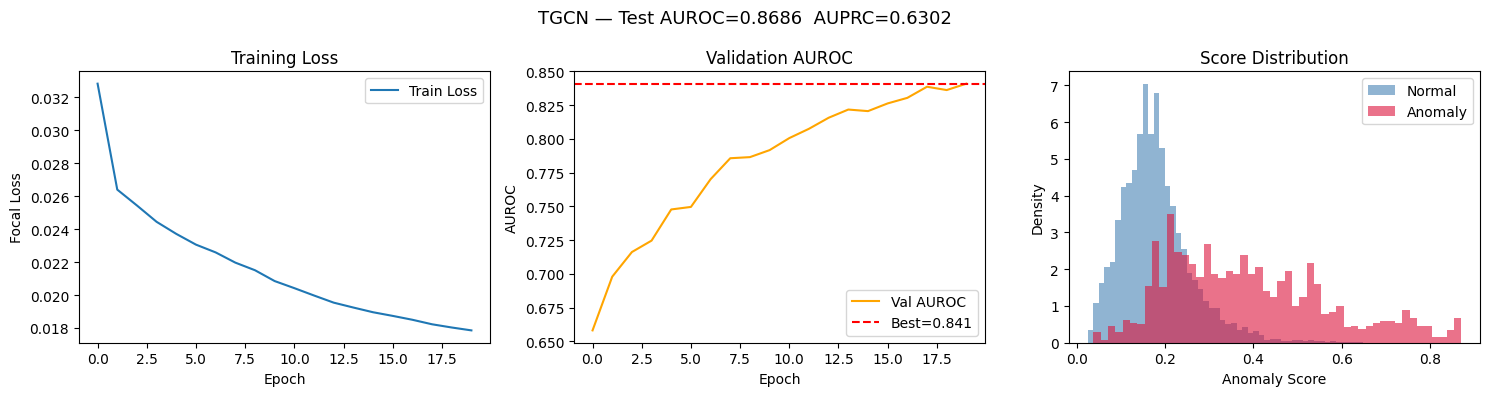

Saved: tgcn_results.png


In [0]:
 
# ─────────────────────────────────────────────────────────────────────────────
# 11. Plots
# ─────────────────────────────────────────────────────────────────────────────
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
# Loss curve
axes[0].plot(train_loss_history, label="Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Focal Loss")
axes[0].set_title("Training Loss")
axes[0].legend()
 
# AUROC curve
axes[1].plot(val_auroc_history, label="Val AUROC", color="orange")
axes[1].axhline(best_val_auroc, linestyle="--", color="red",
                label=f"Best={best_val_auroc:.3f}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUROC")
axes[1].set_title("Validation AUROC")
axes[1].legend()
 
# Score distribution
normal_scores  = all_preds[all_targets == 0]
anomaly_scores = all_preds[all_targets == 1]
axes[2].hist(normal_scores,  bins=50, alpha=0.6,
             color="steelblue", label="Normal",  density=True)
axes[2].hist(anomaly_scores, bins=50, alpha=0.6,
             color="crimson",   label="Anomaly", density=True)
axes[2].set_xlabel("Anomaly Score")
axes[2].set_ylabel("Density")
axes[2].set_title("Score Distribution")
axes[2].legend()
 
plt.suptitle(
    f"TGCN — Test AUROC={test_auroc:.4f}  AUPRC={test_auprc:.4f}",
    fontsize=13
)
plt.tight_layout()
plt.savefig("tgcn_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: tgcn_results.png")